Practical: Implement HPC application for AI/ML domain.

In [1]:
# Import required libraries
import tensorflow as tf
import numpy as np
from tensorflow import keras
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import base64
from io import BytesIO

In [2]:
#Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
#Preprocess Dataset
x_train = x_train.reshape((-1, 28 * 28))
x_test = x_test.reshape((-1, 28 * 28))

# Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Convert labels into categorical (one-hot encoding)
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

In [4]:
#Build Neural Network Model
model = keras.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(28 * 28,)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
#Compile Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
#Train Model

model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_test, y_test)
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9191 - loss: 0.2843 - val_accuracy: 0.9595 - val_loss: 0.1360
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9645 - loss: 0.1211 - val_accuracy: 0.9713 - val_loss: 0.0961
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9756 - loss: 0.0831 - val_accuracy: 0.9728 - val_loss: 0.0928
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9805 - loss: 0.0650 - val_accuracy: 0.9765 - val_loss: 0.0766
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9841 - loss: 0.0510 - val_accuracy: 0.9775 - val_loss: 0.0721
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9875 - loss: 0.0413 - val_accuracy: 0.9810 - val_loss: 0.0605
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9897 - loss: 0.0342 - val_accuracy: 0.9794 - val_loss: 0.0649
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9909 - loss: 0.0288 - val_accu

In [10]:
#Upload Image
uploaded_file = files.upload()

# Load uploaded image
image = Image.open(list(uploaded_file.keys())[0])

# Convert to grayscale and resize to 28x28
image = image.convert('L').resize((28, 28))

Saving digit.png to digit.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


Input,Output
,Uploaded image matches to 5

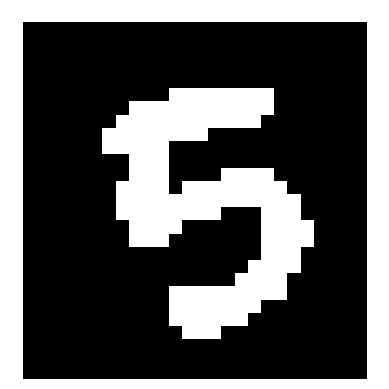

In [11]:
#Preprocess Uploaded Image
# Convert image to numpy array
image_data = np.array(image)

# Invert colors (MNIST uses white digit on black background)
image_data = 255 - image_data

# Apply threshold to make image clean (remove noise)
image_data = (image_data > 128).astype('float32')

# ---- Center the digit ----
coords = np.column_stack(np.where(image_data > 0))
ymin, xmin = coords.min(axis=0)
ymax, xmax = coords.max(axis=0)

# Crop the digit area
digit = image_data[ymin:ymax+1, xmin:xmax+1]

# Resize again to 28x28
digit = Image.fromarray(digit).resize((28, 28))
image_data = np.array(digit)

# Flatten image to match model input
image_data = image_data.reshape((-1, 28 * 28))

#Prediction

prediction = model.predict(image_data)
predicted_digit = np.argmax(prediction[0])


#Display Output in Table Format
# Convert image to base64 for displaying inside HTML
fig, ax = plt.subplots()
ax.imshow(image_data.reshape(28,28), cmap='gray')
ax.axis('off')

buf = BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig)

img_base64 = base64.b64encode(buf.getvalue()).decode()

# Create table
html_code = f"""
<div style="display:flex; justify-content:center;">
<table border="1" style="border-collapse:collapse; text-align:center;">
<tr>
<th>Input</th>
<th>Output</th>
</tr>
<tr>
<td><img src="data:image/png;base64,{img_base64}" width="80"></td>
<td>Uploaded image matches to {predicted_digit}</td>
</tr>
</table>
</div>
"""

# Display table
display(HTML(html_code))
